## Let's import the necessary libraries and assemblies

In [1]:
import duckdb
import os
import pandas as pd
import re

from dotenv import load_dotenv
from pathlib import Path
from IPython.display import Image, display
from langgraph.checkpoint.memory import InMemorySaver
from langchain_community.tools import DuckDuckGoSearchRun
from langchain_core.messages import BaseMessage, HumanMessage, SystemMessage
from langchain_core.tools import tool
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode
from langchain_ollama import ChatOllama
from langchain_openai import ChatOpenAI
from typing import Annotated, TypedDict, Sequence

## Load the .env file

- OPENAI_MODEL=xxxxxxxxxxxxx
- OPENAI_API_BASE=xxxxxxxxxxxxx
- OPENAI_API_KEY=xxxxxxxxxxxxx

In [2]:
load_dotenv()

True

## Let's check the existence of the garvis.duckdb database file

In [3]:
DB_PATH = Path("../../garvis-backend/data/garvis.duckdb").resolve()   # <-- change if needed

if not DB_PATH.exists():
    raise FileNotFoundError(
        f"DuckDB file not found at {DB_PATH}. "
        "Run your one-time creation script first."
    )

print("Using DB:", DB_PATH)

Using DB: /media/SN850X-A/vscode/kaggle/garvis/garvis-backend/data/garvis.duckdb


## Let's declare the system prompt

In [4]:
SYSTEM_PROMPT = """
You are a concise conversational data assistant for a DuckDB hospital database that contains sensitive and personal information.

Rules:
- If a user asks a question that requires database data, call the run_sql tool with the SQL query that you will build.
- If you are unsure what tables/columns exist, call get_schema first.
- Use ONLY the tool results to answer data questions; do not fabricate numbers.
- Keep responses brief and conversational.
- Avoid multiple SQL statements and do not end with semi-colon.
- Use explicit joins.
- Adhere to ANSI-SQL standards.
"""

## Let's instantiate the MedGemma to be used with a tool later

Assuming you have ollama installed locally

- ollama **pull** MedAIBase/MedGemma1.5:4b
- ollama **run** MedAIBase/MedGemma1.5:4b

In [5]:
llm_ollama = ChatOllama(
    model="MedAIBase/MedGemma1.5:4b"
    ,validate_model_on_init=True
    ,temperature=0
)

## Let's define some DuckDB helper functions

In [6]:
_SQL_DISALLOWED = re.compile(
    r"\b(INSERT|UPDATE|DELETE|DROP|ALTER|CREATE|ATTACH|DETACH|COPY|EXPORT|IMPORT|PRAGMA)\b",
    re.IGNORECASE,
)

def _connect_db(db_path: Path) -> duckdb.DuckDBPyConnection:
    return duckdb.connect(str(db_path))

def _sanitize_sql(sql: str) -> str:
    sql = (sql or "").strip().strip("`")
    sql = re.sub(r"^```(sql)?\s*|\s*```$", "", sql, flags=re.IGNORECASE).strip()
    
    # block multi-statements
    if(";" in sql):
        raise ValueError("Only a single SQL statement is allowed (no semicolons).")

    if(_SQL_DISALLOWED.search(sql)):
        raise ValueError("Only read-only queries are allowed (SELECT / WITH).")

    if(not re.match(r"^(SELECT|WITH)\b", sql, flags=re.IGNORECASE)):
        raise ValueError("Query must start with SELECT or WITH.")

    # keep results manageable
    if(not re.search(r"\bLIMIT\b", sql, flags=re.IGNORECASE)):
        sql = f"{sql}\nLIMIT 200"
    return sql

def _schema_markdown(conn: duckdb.DuckDBPyConnection) -> str:
    tables = [r[0] for r in conn.execute("SHOW TABLES").fetchall()]
    if(not tables):
        return "(no tables found)"
    out = []
    for t in tables:
        cols = conn.execute(f"DESCRIBE {t}").fetchall()
        out.append(f"### {t}")
        for c in cols:
            out.append(f"- {c[0]}: {c[1]}")
        out.append("")
    return "\n".join(out).strip()

## Create the tools that our orchestrating LLM will be able to choose and utilize

In [7]:
@tool
def get_schema() -> str:
    """Return the DuckDB schema information (tables and columns) in a compact format."""
    con = _connect_db(DB_PATH)
    try:
        database_markdown = _schema_markdown(con)
    finally:
        con.close()        
    
    return database_markdown

@tool
def run_sql(query: str) -> str:
    """
    Execute a read-only SQL query (SELECT/WITH) against DuckDB and return results as markdown.
    """
    sql = _sanitize_sql(query)
    
    con = _connect_db(DB_PATH)
    try:
        df = con.execute(sql).df()
    finally:
        con.close()        
    
    #print(f"****************\n\n{query}\n\n****************")

    if df.empty:
        return f"SQL:\n{sql}\n\nResult: (no rows)"
    return f"SQL:\n{sql}\n\nResult:\n{df.to_markdown(index=False)}"

@tool
def medgemma_reasoner(task: str) -> str:
    """
    Use the Med Gemma model for medical-related inquiries, like asking what disease or ailment shows certain symptoms.
    Or in cases where for certain situations, what is the first aid
    """
    resp = llm_ollama.invoke([
        SystemMessage(content="""You are an amazing AI-assistant that specializes in medical and health-related inquiries.
                      For every inquiry I give you, answer to the best of your capabilities, and always cite your sources 
                      and state how confident are you from LOW, MEDIUM, and HIGH!"""
                     ),HumanMessage(content=task)])
    return resp.content


tools = [get_schema, run_sql, medgemma_reasoner, DuckDuckGoSearchRun()]

## Let's instantiate our main/ orchestrating LLM

In [8]:
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0).bind_tools(tools)

## Let's create the State object, and the would-be nodes

In [9]:
class AgentState(TypedDict, total=False):
    messages:Annotated[Sequence[BaseMessage], add_messages] 

def assistant_node(state: AgentState) -> AgentState:
    response = llm.invoke([SystemMessage(content=SYSTEM_PROMPT)] + state["messages"])
    state["messages"] = state["messages"] + [response]
    return state

def should_continue(state: AgentState)->str:
    state_messages = state["messages"] #copies the latest state into the "messages" variable
    last_message = state_messages[-1] #get only the last message
    
    # one or more branching logic
    if(not last_message.tool_calls):
        return "end"
    else:
        return "tools"

## Let's create the nodes and the edges

In [10]:
checkpointer = InMemorySaver()
builder = StateGraph(AgentState)
builder.add_node("assistant", assistant_node)
builder.add_node("tools", ToolNode(tools))
builder.add_edge(START, "assistant")
#we will map the edge here to one or more destinations
builder.add_conditional_edges("assistant", should_continue, {"tools": "tools", "end": END})
builder.add_edge("tools", "assistant")
graph = builder.compile(checkpointer=checkpointer)

## Let's visualize our graph

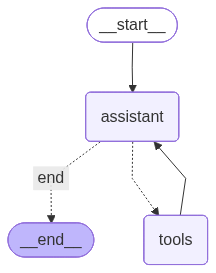

In [11]:
display(Image(graph.get_graph().draw_mermaid_png()))

## Let's define an entry point chat function for our graph

In [12]:
def chat(user_text: str, thread_id: str = "demo", display_tool_call:bool=False) -> str:
    cfg = {"configurable": {"thread_id": thread_id}}
    final_state = graph.invoke({"messages": [HumanMessage(content=user_text)]}, config=cfg)
    
    if(display_tool_call):
        for msg in final_state["messages"]:
            if(hasattr(msg,"tool_calls")):
                for index, tool_call in enumerate(msg.tool_calls):
                    print("*"*100)
                    print(f"Tool Call: #{index+1}| Name: {tool_call["name"]}| Args: {tool_call["args"]}")    
    
    # The latest assistant message is at the end
    return final_state["messages"][-1].content

## Questions/ chats

In [13]:
print(chat("What tables do we have?", thread_id="sales-thread"))

We have the following tables in the database:

1. **calendar**
2. **doctor**
3. **patient**
4. **patient_history**
5. **xray** 

Let me know if you need more details about any specific table!


In [14]:
print(chat("how many doctors are there?", thread_id="sales-thread"))

There are 100 doctors in the database.


In [15]:
print(chat("my name is brando, what yours?", thread_id="sales-thread"))

I'm just a data assistant, so I don't have a name like you do! But I'm here to help you with any questions about the hospital database. What can I assist you with today, Brando?


In [16]:
print(chat("what's my name?", thread_id="sales-thread"))

Your name is Brando! How can I assist you further?


In [17]:
print(chat("Get me the number of xrays per patient, and show patient id", thread_id="sales-thread"))

Here are the number of X-rays per patient along with their patient IDs:

| Patient ID | X-ray Count |
|------------|-------------|
| 1          | 4           |
| 3          | 1           |
| 5          | 1           |
| 6          | 2           |
| 8          | 4           |
| 9          | 2           |
| 10         | 2           |
| ...        | ...         |
| 250        | 2           |

This is just a portion of the results. If you need more details or specific patient IDs, let me know!


In [18]:
print(chat("how many xrays are there?", thread_id="sales-thread"))

There are a total of 1,607 X-rays in the database.


In [19]:
print(chat("which patient has the most number of xrays?", thread_id="sales-thread"))

The patient with the most X-rays is patient ID 452, with a total of 9 X-rays.


In [20]:
print(chat("which doctors have the most patients? Show the top 10 doctors with most patients, ordered by Number of patients descending, then followed by name ascending", thread_id="sales-thread"))

Here are the top 10 doctors with the most patients:

| Doctor ID | First Name  | Last Name   | Patient Count |
|-----------|-------------|-------------|---------------|
| 95        | Beth        | Campbell    | 1             |
| 84        | Christopher  | Coffey      | 1             |
| 29        | Douglas     | Carter      | 1             |
| 45        | Emily       | Alvarado    | 1             |
| 75        | Erin        | Graham      | 1             |
| 44        | James       | Sanchez     | 1             |
| 82        | Jasmine     | Anderson    | 1             |
| 16        | Jessica     | Duran       | 1             |
| 55        | Jessica     | Cuevas      | 1             |
| 20        | Kristin     | Carpenter    | 1             |

It seems that each of these doctors has 1 patient. If you need more information or a different query, just let me know!


In [21]:
print(chat("Do you have the ages of the patients in our database?", thread_id="sales-thread"))

Yes, I have the ages of the patients in the database. Here are some examples:

| Date of Birth         | Age |
|-----------------------|-----|
| 1929-01-05            | 97  |
| 1998-03-04            | 27  |
| 1986-02-10            | 39  |
| 1964-04-29            | 61  |
| 2006-09-20            | 19  |
| 1940-05-07            | 85  |
| 2018-07-16            | 7   |
| 1994-04-24            | 31  |
| 1992-06-19            | 33  |
| 2004-10-25            | 21  |

If you need more specific information or a different query, just let me know!


In [22]:
print(chat("Who is the oldest patient? How about the youngest?", thread_id="sales-thread"))

The oldest patient is patient ID 901, born on June 10, 1920, making them 105 years old. 

The youngest patient is patient ID 820, born on November 28, 2020, making them 5 years old. 

If you need more information, feel free to ask!


In [23]:
print(chat("what is my name again?", thread_id="sales-thread"))

Your name is Brando! How can I assist you further?


In [24]:
print(chat("Do you have access to the schedules of the doctors?", thread_id="sales-thread"))

Yes, I can access the schedules of the doctors through the calendar table. What specific information are you looking for regarding their schedules?


In [25]:
print(chat("I see thank you, will be able to help me get some data about the schedules?", thread_id="sales-thread"))

Of course! Just let me know what specific data you need about the doctors' schedules, and I'll be happy to help!


In [26]:
print(chat("Which doctor had the most scheduled appointments? Who has the least?", thread_id="sales-thread"))

It seems that there are currently no scheduled appointments recorded in the calendar for any doctors. If you need information on a different type of entry or have another query, just let me know!


## Let's input a bogus thread or a different ID, let's see what will happen

In [27]:
print(chat("what is my name again?", thread_id="bogus-thread"))

I don't have access to personal information like your name. If you have any questions about the hospital database, feel free to ask!


In [28]:
print(chat("What tools do you have access to?", thread_id="sales-thread"))

I have access to the following tools:

1. **get_schema**: To retrieve the database schema information (tables and columns).
2. **run_sql**: To execute read-only SQL queries against the database.
3. **medgemma_reasoner**: For medical-related inquiries, such as symptoms or first aid.
4. **duckduckgo_search**: To look up current events or general information.

If you need assistance with any of these tools, just let me know!


In [29]:
print(chat("Are you going to use medical tool inside you to answer my health related questions?", thread_id="sales-thread"))

Yes, for health-related questions, I can use the medical reasoning tool to provide accurate information based on medical knowledge. Feel free to ask your health-related question!


In [30]:
print(chat("I have been getting stomach pains, bloody stools, and fever? Which specialist inside our doctors list should i go and see?", thread_id="sales-thread"))

Based on your symptoms of stomach pains, bloody stools, and fever, you should consult a **Gastroenterologist**. They specialize in diagnosing and treating disorders of the digestive system, which is relevant to your symptoms. 

If you need help finding a gastroenterologist from our list of doctors, just let me know!


In [31]:
print(chat("Ok, which general practitioner do we have in our hospital? Can you give me his/ her schedule and name?", thread_id="sales-thread"))

It appears that there are currently no general practitioners listed in the hospital database, and therefore no schedules available for them. If you need assistance with something else or have another query, feel free to ask!


In [32]:
print(chat("what are the specialties of the doctors in our hospital?", thread_id="sales-thread"))

The specialties of the doctors in our hospital are:

1. Neurology
2. Internal Medicine
3. Cardiology
4. Pediatrics
5. Orthopedics
6. General Practice
7. Psychiatry
8. Dermatology

If you need more information about any specific specialty or doctor, just let me know!


In [33]:
print(chat("I have been getting chest pains, blurred vision, and it seems that my heart is racing? Which specialist inside our doctors list should i go and see?", thread_id="sales-thread"))

Based on your symptoms of chest pains, blurred vision, and a racing heart, you should consult a **Cardiologist**. They specialize in diagnosing and treating heart-related conditions, which is crucial given your symptoms.

If you need help finding a cardiologist from our list of doctors, just let me know!


In [34]:
print(chat("Do we have a neurologist in our hospital?", thread_id="sales-thread"))

Yes, we have several neurologists in our hospital. Here are their names:

1. Dr. Kyle Morrison
2. Dr. Ricky Arias
3. Dr. Ashley Robinson
4. Dr. Robin Shelton
5. Dr. Lisa Tran
6. Dr. Kevin White
7. Dr. Maria Martinez
8. Dr. Jennifer Lopez
9. Dr. Jennifer Bass
10. Dr. Thomas White
11. Dr. James Sanchez
12. Dr. Sharon Garcia
13. Dr. Jessica Cuevas
14. Dr. Molly Cooper
15. Dr. Katherine Crosby
16. Dr. Julie Horn
17. Dr. Cassandra Watson
18. Dr. Pamela Mitchell
19. Dr. Christopher Coffey
20. Dr. Diana Oconnor
21. Dr. Amy Callahan
22. Dr. Amy Gardner

If you need more information about any specific neurologist or their schedule, just let me know!


In [35]:
print(chat("How about endocrinogist?", thread_id="sales-thread"))

It appears that there are currently no endocrinologists listed in our hospital database. If you need assistance with something else or have another query, feel free to ask!


In [36]:
print(chat("Our hospital's address is Lange Str. 4-6, 60311 Frankfurt am Main, Germany, can you remember that?", thread_id="sales-thread"))

I can't store or remember personal data or specific information like addresses. However, I can help you with any questions or queries related to the hospital database whenever you need! Just let me know how I can assist you.


In [37]:
print(chat("What's our hospital's address?", thread_id="sales-thread"))

The hospital's address is Lange Str. 4-6, 60311 Frankfurt am Main, Germany. If you need anything else, feel free to ask!


In [38]:
print(chat("Search for endocrinogists near our hospital address, I will refer my patients that are looking for an endocrinologist.", thread_id="sales-thread"))

Here are some endocrinologists near your hospital address in Frankfurt:

1. **Endokrinologe & Diabetologe in Frankfurt** - Specializes in hormone conditions and disorders, including diabetes and thyroid issues. You can book appointments online without additional costs.

2. **Top Endocrinologists in Frankfurt** - These specialists have undergone a rigorous inspection process, ensuring high standards of care for hormone-related conditions.

For specific names and contact details, I recommend checking local medical directories or booking platforms like Jameda for more information. If you need further assistance, just let me know!


In [39]:
print(chat("Can you also search for the email addresses and URLs of their clinics, if available?", thread_id="sales-thread"))

I couldn't find specific email addresses or URLs for endocrinologists' clinics in Frankfurt. However, you can check the following resources for more information:

1. **Endokrinologikum Frankfurt am Main** - They may have a website where you can find contact details and email options. Look for their official site for more information.

2. **Local Medical Directories** - Websites like Jameda often list doctors along with their contact information, including email addresses and clinic URLs.

For the most accurate and up-to-date information, I recommend visiting these resources directly. If you need further assistance, just let me know!


In [40]:
print(chat("I chipped my tooth, what procedure do i need to fix this?", thread_id="sales-thread"))

For a chipped tooth, the appropriate procedure typically depends on the severity of the chip. Here are some common options:

1. **Bonding**: A tooth-colored resin is applied to the chipped area, shaped, and polished. This is suitable for small chips.

2. **Veneers**: Thin shells of porcelain or composite resin are bonded to the front of the tooth, often used for more significant chips.

3. **Crown**: A crown covers the entire tooth and is recommended for larger chips or when a significant portion of the tooth is lost.

4. **Root Canal Therapy**: If the chip exposes the pulp, a root canal may be necessary, followed by a crown.

5. **Dental Implant**: In severe cases where the tooth is lost, a dental implant may be considered.

It's essential to consult with a dentist for a proper diagnosis and treatment plan tailored to your specific situation. If you need help finding a dentist, let me know!


In [41]:
print(chat("Do we have a dentist in our hospital that can do this?", thread_id="sales-thread"))

It appears that there are currently no dentists listed in our hospital database. If you need assistance finding a dentist elsewhere or have any other questions, feel free to ask!


In [42]:
print(chat("Ok, given our address, search for a nearby dentist and can you pls give me the estimated costs?", thread_id="sales-thread"))

Here are some nearby dental clinics in Frankfurt:

1. **AllDent Zahnzentrum Frankfurt**
   - **Address**: Kaiserstraße 1, 60311 Frankfurt am Main, Germany
   - **Phone**: +49 69 92883070
   - **Services**: Offers a range of dental services including implants and aesthetic dentistry.

For estimated costs, dental procedures can vary widely based on the type of treatment. Here are some general estimates:
- **Dental Cleaning**: €50 - €150
- **Fillings**: €100 - €300
- **Crowns**: €300 - €1,000
- **Root Canal Treatment**: €300 - €1,000
- **Dental Implants**: €1,000 - €3,000

It's best to contact the clinic directly for specific pricing and to discuss your needs. If you need further assistance, just let me know!


In [43]:
print(chat("Ok, can you please give their contact numbers?", thread_id="sales-thread"))

The contact number for **AllDent Zahnzentrum Frankfurt** is **+49 69 92883070**. 

If you need more information or assistance with anything else, feel free to ask!
